In [5]:
# Path setup — works from repo root or notebooks/
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "components" / "config.py").exists():
    root = _cwd
elif (_cwd.parent / "components" / "config.py").exists():
    root = _cwd.parent
else:
    raise RuntimeError(
        "Could not locate project root. Open this notebook from the repo or notebooks/ folder."
    )

sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "retriever"))

from components.config import (
    PROJECT_ROOT,
    PDF_PATH,
    CHUNKS_PATH,
    CHROMA_PATH,
    RAG_EVAL_SUBSET_PATH,
    RAG_DEV_SLICE_PATH,
    RAG_EVAL_LABELS,
    RETRIEVAL_SECTIONS,
    MOOD_DISORDER_PREFIXES,
    DATASET_PATH,
)

print("Project root:", PROJECT_ROOT)
print("PDF:         ", PDF_PATH, "| exists=", PDF_PATH.exists())
print("Chunks:      ", CHUNKS_PATH, "| exists=", CHUNKS_PATH.exists())
print("ChromaDB:    ", CHROMA_PATH, "| exists=", CHROMA_PATH.exists())
print("Final eval:  ", RAG_EVAL_SUBSET_PATH, "| exists=", RAG_EVAL_SUBSET_PATH.exists())
print("Dev slice:   ", RAG_DEV_SLICE_PATH, "| exists=", RAG_DEV_SLICE_PATH.exists())
print("Labels:      ", list(RAG_EVAL_LABELS))
print("Sections:    ", RETRIEVAL_SECTIONS)


Project root: /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026
PDF:          /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/icd_11.pdf | exists= True
Chunks:       /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/icd11_chunks.json | exists= True
ChromaDB:     /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/chroma_db | exists= True
Final eval:   /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/datasets/rag_eval_subset.csv | exists= True
Dev slice:    /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/datasets/rag_dev_slice.csv | exists= True
Labels:       ['suicidal', 'depression', 'normal']
Sections:     ['Essential Features', 'Boundary with Normality']


# Imports

In [6]:
# CELL 2 — Imports

import json, csv, random, re, time, statistics, urllib.request, urllib.error
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from bm25_retriever import BM25Retriever
from hybrid_retriever import HybridRetriever
from dense_retriever import initialise_retrieval, DenseRetriever
from utils import load_chunks, filter_chunks_by_sections, filter_chunks_by_disorder_codes
import components.ingestion as ingestion

print("Imports OK.")


Imports OK.


# Configuration

In [7]:
# CELL 3 — Configuration
# Single dictionary controlling the entire experiment.

CFG = {
    # Ollama API settings
    "ollama_host":     "http://localhost:11434",
    "timeout_s":       1800,
    "num_predict":     512,
    "num_predict_think": 2048,   # thinking needs headroom for the trace + answer
    "num_ctx":         8192,   # Ollama context window (qwen3:0.6b/1.7b max 32768)
    "seed":            42,

    # Models to evaluate
    "models":          ["qwen3:0.6b", "qwen3:1.7b"],

    # Retriever settings (paths from components.config → knowledge_base/)
    "knowledge_base":  str(CHUNKS_PATH),
    "retriever_types": ["bm25", "hybrid", "dense"],
    "top_k_values":    [1, 3, 5],
    "hybrid_alpha":    0.3,         # RRF weight: BM25 vs dense

    # Experiment variables
    "prompt_types":    ["zero_shot", "few_shot"],
    "thinking_modes":  [False, True],
    "debug_unknown": True,

    # Dataset mode:
    #   "dev"   -> rag_dev_slice.csv  (30 posts) for prompt/k tuning / testing
    #   "final" -> rag_eval_subset.csv (450 posts) for reported results
    "eval_mode":       "dev",
    "dataset_path_dev":   str(RAG_DEV_SLICE_PATH),
    "dataset_path_final": str(RAG_EVAL_SUBSET_PATH),
    "text_column":     "text",
    "label_column":    "label",
    "labels":          list(RAG_EVAL_LABELS),
}

if CFG["eval_mode"] == "dev":
    CFG["dataset_path"] = CFG["dataset_path_dev"]
elif CFG["eval_mode"] == "final":
    CFG["dataset_path"] = CFG["dataset_path_final"]
else:
    raise ValueError(f"CFG['eval_mode'] must be 'dev' or 'final', got {CFG['eval_mode']!r}")

print("Configuration loaded.")
print(f"  Eval mode:       {CFG['eval_mode']}")
print(f"  Models:          {CFG['models']}")
print(f"  Retrievers:      {CFG['retriever_types']}")
print(f"  Top-k values:    {CFG['top_k_values']}")
print(f"  Prompt types:    {CFG['prompt_types']}")
print(f"  Thinking modes:  {CFG['thinking_modes']}")
print(f"  Labels:          {CFG['labels']}")
print(f"  Dataset:         {CFG['dataset_path']}")
print(f"  Chunks KB:       {CFG['knowledge_base']}")
print(f"  Sections:        {RETRIEVAL_SECTIONS}")


Configuration loaded.
  Eval mode:       dev
  Models:          ['qwen3:0.6b', 'qwen3:1.7b']
  Retrievers:      ['bm25', 'hybrid', 'dense']
  Top-k values:    [1, 3, 5]
  Prompt types:    ['zero_shot', 'few_shot']
  Thinking modes:  [False, True]
  Labels:          ['suicidal', 'depression', 'normal']
  Dataset:         /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/datasets/rag_dev_slice.csv
  Chunks KB:       /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/icd11_chunks.json
  Sections:        ['Essential Features', 'Boundary with Normality']


In [8]:
# CELL 3b — Run profile (edit QUICK_TEST / FINAL_REPORT)

QUICK_TEST = True   # True = small grid for end-to-end testing from this notebook
FINAL_REPORT = False  # True = full 450-post reporting set (disables QUICK_TEST)

if FINAL_REPORT:
    QUICK_TEST = False
    CFG["eval_mode"] = "final"
    CFG["dataset_path"] = CFG["dataset_path_final"]
    print("FINAL REPORT MODE — 450-post eval set; lock prompts before using this.")
elif QUICK_TEST:
    CFG["eval_mode"] = "dev"
    CFG["dataset_path"] = CFG["dataset_path_dev"]
    CFG["models"] = ["qwen3:0.6b"]
    CFG["retriever_types"] = ["bm25", "hybrid", "dense"]
    CFG["top_k_values"] = [3]
    CFG["prompt_types"] = ["zero_shot"]
    CFG["thinking_modes"] = [False]
    print("QUICK TEST MODE — dev slice (30), 1 model, 3 retrievers, k=3, zero-shot")
else:
    print("FULL DEV MODE — using CFG from Cell 3 as-is (eval_mode=" + CFG["eval_mode"] + ")")

print(f"  eval_mode={CFG['eval_mode']}")
print(f"  dataset={CFG['dataset_path']}")
print(f"  models={CFG['models']}")
print(f"  retrievers={CFG['retriever_types']}")
print(f"  top_k={CFG['top_k_values']}")
print(f"  prompts={CFG['prompt_types']}")
print(f"  thinking={CFG['thinking_modes']}")


QUICK TEST MODE — dev slice (30), 1 model, 3 retrievers, k=3, zero-shot
  eval_mode=dev
  dataset=/Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/datasets/rag_dev_slice.csv
  models=['qwen3:0.6b']
  retrievers=['bm25', 'hybrid', 'dense']
  top_k=[3]
  prompts=['zero_shot']
  thinking=[False]


# Prompt Builder

In [9]:
# CELL 4 — Prompt Builder

# This cell defines the prompt sent to the LLM with optional retrieval context.
# We force a fixed two-line reply format for consistent parsing.

SYSTEM_PROMPT = (
    "You are a mental-health risk classifier for social-media posts. "
    "You must reply with ONLY these two lines, nothing else:\n"
    "Label: <suicidal|depression|normal>\n"
    "Reason: <one sentence>\n"
    "Do NOT give advice. Do NOT explain. Just the two lines above."
)

# Zero-shot: no examples, just the system prompt + retrieved chunks + post
ZERO_SHOT_TEMPLATE = """\
{system}

Post: {post}

Answer:"""

# Few-shot: adds 3 labeled examples before the post to guide the model
FEW_SHOT_TEMPLATE = """\
{system}

Examples:
Post: "Had a long day at work but hanging out with friends tonight. Feeling okay overall."
Label: normal — Everyday stress without persistent depressive or suicidal content.

Post: "I've been sad most days, struggling to enjoy anything, sleep is off, and I feel worthless."
Label: depression — Persistent low mood and impairment without active suicidal intent.

Post: "I don't see the point in living anymore. I've been thinking about ending it."
Label: suicidal — Explicit passive or active suicidal ideation.

---
Post: {post}

Answer:"""

# Template for injecting retrieved CDDR chunks between the system prompt and the post
RETRIEVAL_BLOCK_TEMPLATE = """\

Relevant clinical knowledge:
{chunks}
---
"""

def build_prompt(post: str, prompt_type: str,
                 retrieved_chunks: list[dict]) -> str:
    """Assemble the final prompt from template + optional retrieved chunks.

    Args:
        post:             The social media post to classify.
        prompt_type:      "zero_shot" or "few_shot"
        retrieved_chunks: List of chunk dicts returned by the retriever.
                          Empty list = no retrieval (baseline condition).
    Returns:
        The complete prompt string ready to send to Ollama.
    """
    # Format retrieved chunks as a numbered list if any were returned
    chunk_text = ""
    if retrieved_chunks:
        bullets = "\n".join(
            f"[{i+1}] ({c.get('disorder_name', '')} — {c.get('section', '')}): "
            f"{c.get('prompt_text', c.get('text', ''))}"
            for i, c in enumerate(retrieved_chunks)
        )
        chunk_text = RETRIEVAL_BLOCK_TEMPLATE.format(chunks=bullets)

    # Attach retrieval block to system prompt, then fill in the template
    template = ZERO_SHOT_TEMPLATE if prompt_type == "zero_shot" else FEW_SHOT_TEMPLATE
    full_system = SYSTEM_PROMPT + chunk_text
    return template.format(system=full_system, post=post)

# Sanity check prints the assembled prompt for a sample post
sample_chunks = [{"text": "Depressed mood: persistent low mood most of the day..."}]
print(build_prompt("I feel really hopeless lately.", "zero_shot", sample_chunks))


You are a mental-health risk classifier for social-media posts. You must reply with ONLY these two lines, nothing else:
Label: <suicidal|depression|normal>
Reason: <one sentence>
Do NOT give advice. Do NOT explain. Just the two lines above.
Relevant clinical knowledge:
[1] ( — ): Depressed mood: persistent low mood most of the day...
---


Post: I feel really hopeless lately.

Answer:


# Load Dataset

In [10]:
# CELL 5 — Load Dataset
# Loads the active eval file selected by CFG["eval_mode"]:
#   dev   -> rag_dev_slice.csv  (30 stratified posts for tuning)
#   final -> rag_eval_subset.csv (450 stratified posts for reporting)


def load_dataset(cfg: dict) -> pd.DataFrame:
    # We defined the csv field size limit because the default one is quite small
    csv.field_size_limit(10_000_000)
    path = cfg["dataset_path"]
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            text  = (r.get(cfg["text_column"])  or "").strip()
            label = (r.get(cfg["label_column"]) or "").strip().lower()
            # Skip rows with missing text or labels not in our valid label set
            if text and label in cfg["labels"]:
                row = {"text": text, "label": label}
                if r.get("row_id"):
                    row["row_id"] = r["row_id"]
                if r.get("parent_row_id"):
                    row["parent_row_id"] = r["parent_row_id"]
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f"Eval mode: {cfg['eval_mode']}")
    print(f"Loaded from: {path}")
    print(f"Total usable rows: {len(df)}")
    print(df["label"].value_counts().to_string())
    return df.reset_index(drop=True)

df_posts = load_dataset(CFG)
df_posts.head()


Eval mode: dev
Loaded from: /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/datasets/rag_dev_slice.csv
Total usable rows: 30
label
suicidal      10
depression    10
normal        10


,text,label,row_id,parent_row_id
0,(I live in Canada) I was thinking of ending it...,suicidal,dev_0000,rag_0000
1,I am alone and broken I just feel nothing I ca...,suicidal,dev_0001,rag_0030
2,"I am pretty much at a low point, maybe not my ...",suicidal,dev_0002,rag_0039
3,I hate myself. My head is so messed up and my ...,suicidal,dev_0003,rag_0057
4,"I just want out of this world, I have to many ...",suicidal,dev_0004,rag_0067


# Build Retrievers

In [11]:
import components.ingestion as ingestion
print("embedding model:", ingestion._embedding_model)
print("collection:", ingestion._collection)

embedding model: None
collection: None


In [12]:
def build_retrievers(cfg: dict) -> dict:
    kb = cfg["knowledge_base"]
    print(f"Building retrievers from: {kb}")
    assert Path(kb).exists(), f"Knowledge base not found at {kb}"

    # Restrict retrieval to mood-disorder ICD-11 content (6A6–6A8).
    # Without this, section filtering still leaves ~330 non-mood chunks
    # (substance use, PTSD, etc.) that pollute suicide/depression risk classification.
    all_chunks = load_chunks(kb)
    mood_chunks = filter_chunks_by_disorder_codes(all_chunks, MOOD_DISORDER_PREFIXES)
    mood_chunks = filter_chunks_by_sections(mood_chunks, RETRIEVAL_SECTIONS)
    print(
        f"Mood-disorder retrieval pool: {len(mood_chunks)} chunks "
        f"(from {len(all_chunks)} total)"
    )

    print(f"ChromaDB path: {CHROMA_PATH}")
    initialise_retrieval(chroma_path=str(CHROMA_PATH))

    retrievers = {}

    print("  → BM25   ...", end=" ", flush=True)
    retrievers["bm25"] = BM25Retriever(
        chunks=mood_chunks,
        sections=RETRIEVAL_SECTIONS,
    )

    print("  → Hybrid ...", end=" ", flush=True)
    retrievers["hybrid"] = HybridRetriever(
        chunks=mood_chunks,
        alpha=cfg["hybrid_alpha"],
        sections=RETRIEVAL_SECTIONS,
    )

    print("  → Dense ...", end=" ", flush=True)
    retrievers["dense"] = DenseRetriever(
        sections=RETRIEVAL_SECTIONS,
        json_path=kb,
    )

    print("\nAll retrievers ready.")
    return retrievers

retrievers = build_retrievers(CFG)


Building retrievers from: /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/icd11_chunks.json
Mood-disorder retrieval pool: 28 chunks (from 1569 total)
ChromaDB path: /Users/omarhalasa/Desktop/AI Group Project/Github/AI-group-project-2026/knowledge_base/chroma_db


/Users/omarhalasa/.pyenv/versions/3.12.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading embedding model on cpu …
Ready. Collection 'icd11_clinical' has 1569 vectors.
  → BM25   ... BM25 retriever ready: 28 chunks indexed
  → Hybrid ... BM25 retriever ready: 28 chunks indexed
  → Dense ... 
All retrievers ready.


In [13]:
# Runs a quick sanity check on all three retrievers using a sample depression post.
# Verifies each retriever loads correctly, returns results, and that chunk fields
# (disorder_name, section, text/prompt_text) are present and non-empty.
# Run this cell after build_retrievers() succeeds and before the experiment grid.

TEST_QUERY = (
    "I have been feeling hopeless and exhausted for weeks. "
    "I can't sleep, lost interest in everything, and I cry most days."
)
TEST_K = 3

print("Test query:", TEST_QUERY[:80], "...")
print()
print("=" * 70)

all_passed = True

for name, retriever in retrievers.items():
    print()
    print("[" + name.upper() + "]")
    try:
        results = retriever.search(TEST_QUERY, k=TEST_K)

        if not results:
            print("  WARN  - returned 0 results (is the knowledge base populated?)")
            all_passed = False
        else:
            print("  OK    - returned", len(results), "chunk(s)")
            for i, chunk in enumerate(results):
                disorder = chunk.get("disorder_name", chunk.get("disorder_code", "<no disorder>"))
                section  = chunk.get("section", "<no section>")
                text     = chunk.get("prompt_text", chunk.get("text", ""))
                score = chunk.get("score", chunk.get("bm25_score", chunk.get("dense_score", None)))
                score_str = ("  score=" + "{:.4f}".format(score)) if score is not None else ""
                # Hybrid RRF results also expose per-retriever ranks.
                rank_str = ""
                if "bm25_rank" in chunk or "dense_rank" in chunk:
                    rank_str = (
                        "  bm25_rank=" + str(chunk.get("bm25_rank"))
                        + "  dense_rank=" + str(chunk.get("dense_rank"))
                    )
                print("  [" + str(i + 1) + "] " + str(disorder) + " - " + str(section) + score_str + rank_str)
                print("       " + str(text).strip())

            missing_fields = []
            for field in ["disorder_name", "section"]:
                if not any(c.get(field) for c in results):
                    missing_fields.append(field)
            if not any(c.get("prompt_text") or c.get("text") for c in results):
                missing_fields.append("text/prompt_text")
            if missing_fields:
                print("  WARN  - these fields are missing or empty:", missing_fields)
                print("         build_prompt() will format chunks without them.")
                all_passed = False
            else:
                print("  PASS  - all expected chunk fields present")

    except Exception as e:
        print("  FAIL  -", type(e).__name__ + ":", str(e))
        all_passed = False

print()
print("=" * 70)
if all_passed:
    print("ALL RETRIEVERS PASSED - safe to proceed to experiment grid.")
else:
    print("ONE OR MORE CHECKS FAILED - review warnings above before running the grid.")


Test query: I have been feeling hopeless and exhausted for weeks. I can't sleep, lost intere ...


[BM25]
  OK    - returned 6 chunk(s)
  [1] Mood disorder, unspecified - Essential Features  score=8.0238
       • The concurrent presence of at least five of the following characteristic symptoms occurring for most of the day, nearly every day, during a period lasting at least 2 weeks is required for diagnosis. At least one symptom from the affective cluster must be present. Assessment of the presence or absence of symptoms should be made relative to typical functioning of the individual. Affective cluster • Depressed mood as reported by the individual (e.g. feeling down, sad) or as observed (e.g. tearful, defeated appearance) (Note: in children and adolescents depressed mood can manifest as irritability.) • Markedly diminished interest or pleasure in activities, especially those normally found to be enjoyable to the individual (Note: this may include a reduction in sexual desire.) Cognit

# Ollama Helpers

In [14]:
# CELL 7 — Ollama Helpers
# In this cell we defines the functions that will help us communicate with Ollama API

# Sends a POST request to Ollama and returns the response
def _http_post(host: str, path: str, payload: dict, timeout: int) -> dict:
    # Sends a JSON POST request to the Ollama API and returns the parsed response
    req = urllib.request.Request(
        host + path,
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode())

# Confirms Ollama is running and required models are pulled
def check_ollama(cfg: dict) -> list[str]:
    req = urllib.request.Request(cfg["ollama_host"] + "/api/tags")
    with urllib.request.urlopen(req, timeout=10) as r:
        data = json.loads(r.read().decode())
    installed = [m["name"] for m in data.get("models", [])]
    print("Ollama is running. Installed models:")
    for m in installed:
        print(f"  {m}")
    missing = [m for m in cfg["models"]
               if not any(i == m or i.startswith(m) for i in installed)]
    if missing:
        print(f"\nWARNING — these models are not pulled yet: {missing}")
        print("Run:  ollama pull <model>  for each one before the grid sweep.")
    return installed

installed_models = check_ollama(CFG)

#  Extracts the classification label from the model's output
# def _parse_label(text: str, valid_labels: list[str]) -> str:
#     # Parse only the model answer — not retrieved ICD text that may contain
#     # depression / suicide in a clinical sense unrelated to the predicted label.
#     answer = text.strip().splitlines()[0] if text.strip() else ""
#     match = re.search(r"label:\s*(\w+)", answer.lower())
#     if match and match.group(1) in valid_labels:
#         return match.group(1)
#     # Fallback: whole-word match on the first line only (longest label first).
#     for label in sorted(valid_labels, key=len, reverse=True):
#         if re.search(rf"\b{re.escape(label)}\b", answer.lower()):
#             return label
#     return "unknown"
LABEL_ALIASES = {
    "suicidal": "suicidal", "suicide": "suicidal", "suicidality": "suicidal",
    "suicidal_ideation": "suicidal", "self-harm": "suicidal",
    "depression": "depression", "depressed": "depression",
    "depressive": "depression", "depressive_episode": "depression",
    "normal": "normal", "none": "normal", "healthy": "normal",
    "non-suicidal": "normal", "no_risk": "normal",
}

def _parse_label(text: str, valid_labels: list[str]) -> str:
    if not text.strip():
        return "unknown"
    lines = text.strip().splitlines()
    # 1. Explicit "Label: X" anywhere in the answer
    m = re.search(r"label\s*[:\-]\s*([a-z_\- ]+)", text.lower())
    if m:
        cand = m.group(1).strip().split()[0].strip(".,;*")
        if cand in LABEL_ALIASES:
            return LABEL_ALIASES[cand]
    # 2. Whole-word alias match on the first line
    first = lines[0].lower()
    for alias, canon in sorted(LABEL_ALIASES.items(), key=lambda x: -len(x[0])):
        if re.search(rf"\b{re.escape(alias)}\b", first):
            return canon
    return "unknown"

# Separates the thinking trace from the actual answer
def _split_thinking(response_text: str, thinking_field: str) -> tuple[str, str]:
    # Newer Ollama versions return thinking in a separate field
    if thinking_field:
        return thinking_field.strip(), response_text.strip()
    # Older versions embed thinking inline as <think>...</think> tags
    m = re.search(r"<think>(.*?)</think>", response_text, re.DOTALL)
    if m:
        return m.group(1).strip(), response_text[m.end():].strip()
    # Thinking mode was off — return empty thinking and full response as answer
    return "", response_text.strip()

# Sends a prompt to a model and returns timing + output
def call_ollama(prompt: str, model: str, think: bool, cfg: dict) -> dict:
    # Builds the request payload and sends it to Ollama
    payload = {
        "model":  model,
        "prompt": prompt,
        "think":  think,   # toggles Qwen3 thinking/reasoning mode
        "stream": False,   # wait for full response before returning
        "options": {
            "seed":        cfg["seed"],        # fixed for reproducibility
            "temperature": 0.0,
            "top_p": 1.0,
            "num_predict": cfg["num_predict_think"] if think else cfg["num_predict"], # max tokens to generate
            "num_ctx":     cfg.get("num_ctx", 8192),  # context window size
        },
    }
    t0 = time.perf_counter()
    resp = _http_post(cfg["ollama_host"], "/api/generate", payload, cfg["timeout_s"])
    wall_s = time.perf_counter() - t0

    raw_response   = resp.get("response", "")
    thinking_field = resp.get("thinking", "") or ""
    thinking_text, answer_text = _split_thinking(raw_response, thinking_field)

    gen_eval_s = resp.get("eval_duration", 0) / 1e9
    gen_tokens  = resp.get("eval_count", 0)

    return {
        "wall_s":        round(wall_s, 3),
        "total_s":       round(resp.get("total_duration", 0) / 1e9, 3),
        "prompt_tokens": resp.get("prompt_eval_count", 0),
        "gen_tokens":    gen_tokens,
        "tok_per_s":     round(gen_tokens / gen_eval_s, 2) if gen_eval_s else 0.0,
        "thinking_text": thinking_text,
        "answer_text":   answer_text,
        "hit_cap":       gen_tokens >= cfg["num_predict"], # True if model hit the token limit
    }

print("Ollama helpers ready.")


Ollama is running. Installed models:
  qwen3:4b
  qwen3:1.7b
  qwen3:0.6b
  deepseek-r1:1.5b
Ollama helpers ready.


# Pipeline Runner

In [15]:
# CELL 8 — Pipeline Runner
# run_single() is the core of the pipeline. It takes one post and one
# experiment configuration, runs it through the full RAG pipeline, and
# returns a results dict with the prediction, timing, and retrieved chunks.
# Called once per post per configuration in the experiment grid.


def run_single(
    post: str,
    true_label: str,
    model: str,
    retriever_type: str,
    top_k: int,
    prompt_type: str,
    think: bool,
    retrievers: dict,
    cfg: dict,
) -> dict:

    # Step 1 — Retrieve top-k relevant CDDR chunks for this post
    t_ret = time.perf_counter()
    if top_k <= 0:
        chunks = []  # no-retrieval baseline (RQ5)
    else:
        chunks = retrievers[retriever_type].search(post, k=top_k)
    retrieval_s = round(time.perf_counter() - t_ret, 4)

    # Step 2 — Assemble the prompt (system + retrieved chunks + post)
    prompt = build_prompt(post, prompt_type, chunks)

    # Step 3 — Send prompt to the LLM and get response + timing
    llm_out = call_ollama(prompt, model, think, cfg)

    # Step 4 — Extract the predicted label from the model's raw output
    predicted = _parse_label(llm_out["answer_text"], cfg["labels"])
    
    # Diagnostic: surface parse failures instead of letting them score as wrong
    if predicted == "unknown" and cfg.get("debug_unknown", True):
        print(f"    [UNKNOWN PARSE] true={true_label} | hit_cap={llm_out['hit_cap']}")
        print(f"      raw: {llm_out['answer_text'][:200]!r}")

    return {
        # Experiment configuration axes
        "model":           model,
        "retriever":       retriever_type,
        "top_k":           top_k,
        "prompt_type":     prompt_type,
        "think":           think,
        # Ground truth and prediction
        "true_label":      true_label,
        "predicted":       predicted,
        "correct":         int(predicted == true_label),
        # Timing
        "retrieval_s":     retrieval_s,
        "llm_total_s":     llm_out["total_s"],
        "tok_per_s":       llm_out["tok_per_s"],
        "prompt_tokens":   llm_out["prompt_tokens"],
        "gen_tokens":      llm_out["gen_tokens"],
        "hit_cap":         llm_out["hit_cap"],
        # Retrieved evidence (kept for retrieval quality analysis)
        "chunks_returned": len(chunks),
        "chunk_ids": [c.get("id", c.get("disorder_code", "")) for c in chunks],
        # Raw model output (kept for error analysis)
        "answer_text":     llm_out["answer_text"],
        "thinking_text":   llm_out["thinking_text"],
    }

print("run_single() defined.")

run_single() defined.


In [16]:
# CELL 9 — Model Warmup
# Sends one dummy call to each model before the timed experiment grid.
# Without this, the first real post would be slower than the rest because
# Ollama needs to load the model weights into RAM on the first call.
# Warmup results are discarded — only used to pre-load the model.

print("Warming up models (one call each, results discarded) ...")
for model in CFG["models"]:
    try:
        call_ollama("Hello", model, False, CFG)
        print(f"  ✓ {model}")
    except Exception as e:
        print(f"  ✗ {model}  — {e}")
print("Warmup done.")

Warming up models (one call each, results discarded) ...
  ✓ qwen3:0.6b
Warmup done.


In [17]:
# CELL 10 — Full Experiment Grid (COMMENTED OUT — use Cell 12 instead)
# Runs every possible combination of all CFG variables using itertools.product.
# With current CFG this produces:
#   2 models × 3 retrievers × 4 top-k × 2 prompt types × 2 thinking modes
#   = 96 configurations × 50 posts = 4800 LLM calls
# Estimated time on CPU: many hours — not practical for development.
# Use the targeted grid in Cell 12 which runs ~1000 calls instead.


# # Build all combinations of experiment variables into a flat list of tuples
# grid = list(product(
#     CFG["models"],
#     CFG["retriever_types"],
#     CFG["top_k_values"],
#     CFG["prompt_types"],
#     CFG["thinking_modes"],
# ))
# total_calls = len(grid) * len(df_posts)
# print(f"Grid size: {len(grid)} configurations × {len(df_posts)} posts = {total_calls} LLM calls")
# print("This will take a while on CPU. Consider reducing models/top_k_values/sample_size for dev runs.\n")
#
# # Loop over every configuration, then every post within each configuration
# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     config_label = (f"{model} | {retriever_type} | k={top_k} | "
#                     f"{prompt_type} | think={think}")
#     print(f"\n[{config_idx+1}/{len(grid)}] {config_label}")
#
#     for post_idx, row in df_posts.iterrows():
#         try:
#             # Run one post through the full pipeline for this configuration
#             result = run_single(
#                 post          = row["text"],
#                 true_label    = row["label"],
#                 model         = model,
#                 retriever_type= retriever_type,
#                 top_k         = top_k,
#                 prompt_type   = prompt_type,
#                 think         = think,
#                 retrievers    = retrievers,
#                 cfg           = CFG,
#             )
#             all_results.append(result)
#             status = "✓" if result["correct"] else "✗"
#             print(f"  {status} post{post_idx:02d} | "
#                   f"true={result['true_label']:8} pred={result['predicted']:8} | "
#                   f"llm={result['llm_total_s']:.1f}s  ret={result['retrieval_s']:.3f}s")
#         except Exception as e:
#             # Log errors per post without stopping the whole run
#             print(f"  ERROR post{post_idx}: {e}")
#
# # Save all results to CSV and display first few rows
# df_results = pd.DataFrame(all_results)
# df_results.to_csv("rag_results_raw.csv", index=False)
# print(f"\nDone. {len(df_results)} rows saved to rag_results_raw.csv")
# df_results.head()

# Experiment

In [18]:
# CELL 11 — Targeted Experiment Grid
# Instead of running every possible combination (Cell 10), this cell runs
# a targeted grid that answers five specific research questions (RQs).
# Each RQ isolates one variable while keeping the others fixed.
# Total: 6 configurations × 50 posts = 300 LLM calls (~3 mins on CPU)

grid = []

# RQ1: How does top-k affect BM25 classification accuracy?
# Sweeps BM25 across top-k values with everything else fixed
for k in [1, 3, 5, 7]:
    grid.append(("qwen3:0.6b", "bm25", k, "zero_shot", False))

# RQ2: Does model size affect BM25 classification accuracy?
# Compares 0.6b vs 1.7b using BM25 at k=5
for model in ["qwen3:0.6b", "qwen3:1.7b"]:
    grid.append((model, "bm25", 5, "zero_shot", False))

# RQ3: Does thinking mode improve BM25 accuracy?
# Adds thinking ON for 0.6b — compare against RQ2's 0.6b thinking OFF result
grid.append(("qwen3:0.6b", "bm25", 5, "zero_shot", True))

# RQ4: Does few-shot prompting improve BM25 over zero-shot?
# Same config as RQ2 0.6b but with few-shot examples in the prompt
grid.append(("qwen3:0.6b", "bm25", 5, "few_shot", False))

# RQ5: Does RAG actually help? (no-retrieval baseline)
# k=0 means no chunks are retrieved — prompt contains only the post
# Compare this against RQ1 results to measure RAG's contribution
grid.append(("qwen3:0.6b", "bm25", 0, "zero_shot", False))

# RQ1 (k sweep) and RQ2 (model size) both include 0.6b/bm25/k=5/zero_shot/False.
# Deduplicate so the config isn't run twice and averaged against itself (n=60 bug).
seen = set()
grid = [g for g in grid if not (g in seen or seen.add(g))]

# Print the full grid before running so it can be reviewed
posts_to_run = df_posts  # full active set (dev=30 or final=450)
total_calls = len(grid) * len(posts_to_run)
out_file = "rag_results_final.csv"

print(f"Grid: {len(grid)} configs × {len(posts_to_run)} posts = {total_calls} calls")
print(f"Output: {out_file}")
print(f"Est. time: ~{total_calls * 0.5 / 60:.1f} min\n")
for i, (m, r, k, p, t) in enumerate(grid):
    print(f"  [{i+1:2d}] {m:14} {r:8} k={k} {p:10} think={t}")

# Run the grid — try/finally ensures partial results are saved even if
# the run crashes or is interrupted halfway through
all_results = []
try:
    for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
        label = f"{model} | {retriever_type} | k={top_k} | {prompt_type} | think={think}"
        print(f"\n[{config_idx+1}/{len(grid)}] {label}")

        for post_idx, row in posts_to_run.iterrows():
            try:
                result = run_single(
                    post=row["text"], true_label=row["label"],
                    model=model, retriever_type=retriever_type,
                    top_k=top_k, prompt_type=prompt_type,
                    think=think, retrievers=retrievers, cfg=CFG,
                )
                all_results.append(result)
                s = "✓" if result["correct"] else "✗"
                print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
            except Exception as e:
                # Log errors per post without stopping the whole run
                print(f"  ERROR post{post_idx}: {e}")

finally:
    # Always save whatever results were collected — even on crash or interrupt
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(out_file, index=False)
        print(f"\nSaved {len(df_results)} rows to {out_file}")


Grid: 8 configs × 30 posts = 240 calls
Output: rag_results_final.csv
Est. time: ~2.0 min

  [ 1] qwen3:0.6b     bm25     k=1 zero_shot  think=False
  [ 2] qwen3:0.6b     bm25     k=3 zero_shot  think=False
  [ 3] qwen3:0.6b     bm25     k=5 zero_shot  think=False
  [ 4] qwen3:0.6b     bm25     k=7 zero_shot  think=False
  [ 5] qwen3:1.7b     bm25     k=5 zero_shot  think=False
  [ 6] qwen3:0.6b     bm25     k=5 zero_shot  think=True
  [ 7] qwen3:0.6b     bm25     k=5 few_shot   think=False
  [ 8] qwen3:0.6b     bm25     k=0 zero_shot  think=False

[1/8] qwen3:0.6b | bm25 | k=1 | zero_shot | think=False
  ✓ post00 | true=suicidal pred=suicidal | llm=1.0s
  ✓ post01 | true=suicidal pred=suicidal | llm=1.2s
  ✓ post02 | true=suicidal pred=suicidal | llm=1.1s
  ✓ post03 | true=suicidal pred=suicidal | llm=0.4s
  ✓ post04 | true=suicidal pred=suicidal | llm=0.9s
  ✓ post05 | true=suicidal pred=suicidal | llm=0.8s
  ✓ post06 | true=suicidal pred=suicidal | llm=1.3s
  ✓ post07 | true=suicidal

In [19]:
# # CELL 11a — Smoke Test Grid (TEMPORARY — remove with Cell 3b)
# # Runs a single configuration on 5 posts to confirm the pipeline works
# # end-to-end before committing to the full experiment grid.
# # REMOVE THIS CELL once real ICD-11 CDDR chunks are ready and replace
# # with Cell 12 (targeted grid) for the actual experiment run.


# grid = [("qwen3:0.6b", "bm25", 3, "zero_shot", False)]
# posts_to_run = df_posts  # already limited to 5 by CFG override in Cell 4

# total_calls = len(grid) * len(posts_to_run)
# print(f"Smoke test: {len(grid)} config × {len(posts_to_run)} posts = {total_calls} LLM calls")

# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     print(f"\n[{config_idx+1}/{len(grid)}] {model} | {retriever_type} | k={top_k} | {prompt_type} | think={think}")

#     for post_idx, row in posts_to_run.iterrows():
#         try:
#             result = run_single(
#                 post=row["text"], true_label=row["label"],
#                 model=model, retriever_type=retriever_type,
#                 top_k=top_k, prompt_type=prompt_type,
#                 think=think, retrievers=retrievers, cfg=CFG,
#             )
#             all_results.append(result)
#             s = "✓" if result["correct"] else "✗"
#             print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
#         except Exception as e:
#             print(f"  ERROR post{post_idx}: {e}")

# df_results = pd.DataFrame(all_results)
# print(f"\nDone. {len(df_results)} rows saved.")
# df_results.head()

In [20]:
# CELL 13 — Results Summary
# Aggregates raw results into a summary table grouped by experiment variables.
# For each configuration computes:
#   n          — number of posts evaluated
#   accuracy   — proportion of correct predictions
#   macro_f1   — macro-averaged F1 across all three labels (main metric)
#                macro-F1 is preferred over accuracy here because it treats
#                all classes equally regardless of their size in the sample
#   mean_llm_s — average LLM inference time per post
#   mean_ret_s — average retrieval time per post

def summarise(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    records = []
    for keys, grp in df.groupby(group_cols):
        # groupby returns a scalar when grouping by one column, tuple for multiple
        if not isinstance(keys, tuple):
            keys = (keys,)
        rec = dict(zip(group_cols, keys))
        rec["n"]        = len(grp)
        rec["accuracy"] = round(grp["correct"].mean(), 4)
        rec["unknown_rate"] = round((grp["predicted"] == "unknown").mean(), 4)
        # macro-F1 requires predictions for all labels to be meaningful —
        # use try/except to handle edge cases where a label has no predictions
        try:
            rec["macro_f1"] = round(
                f1_score(grp["true_label"], grp["predicted"],
                         labels=CFG["labels"], average="macro",
                         zero_division=0), 4)
        except Exception:
            rec["macro_f1"] = float("nan")
        rec["mean_llm_s"] = round(grp["llm_total_s"].mean(), 2)
        rec["mean_ret_s"] = round(grp["retrieval_s"].mean(), 4)
        records.append(rec)
    # Sort by macro_f1 descending so best configurations appear first
    return pd.DataFrame(records).sort_values("macro_f1", ascending=False)

# Summarise at the full configuration level — one row per unique combination
# of model, retriever, top_k, prompt_type, and thinking mode
df_summary = summarise(
    df_results,
    ["model", "retriever", "top_k", "prompt_type", "think"]
)
print("Top 10 configurations by macro-F1:")
df_summary.head(10)


Top 10 configurations by macro-F1:


,model,retriever,top_k,prompt_type,think,n,accuracy,unknown_rate,macro_f1,mean_llm_s,mean_ret_s
5,qwen3:0.6b,bm25,5,zero_shot,True,30,0.7333,0.0,0.7296,10.94,0.0055
1,qwen3:0.6b,bm25,1,zero_shot,False,30,0.5333,0.0,0.4650,0.84,0.0011
0,qwen3:0.6b,bm25,0,zero_shot,False,30,0.5000,0.0,0.4554,0.71,0.0000
2,qwen3:0.6b,bm25,3,zero_shot,False,30,0.5000,0.0,0.4456,1.21,0.0012
4,qwen3:0.6b,bm25,5,zero_shot,False,30,0.5000,0.0,0.4445,1.55,0.0014
3,qwen3:0.6b,bm25,5,few_shot,False,30,0.5333,0.0,0.4379,2.63,0.0013
6,qwen3:0.6b,bm25,7,zero_shot,False,30,0.4667,0.0,0.3778,1.90,0.0020
7,qwen3:1.7b,bm25,5,zero_shot,False,30,0.4333,0.0,0.3749,6.13,0.0053


In [21]:
cap = df_results.groupby(["model", "think", "top_k"]).agg(
    n=("hit_cap", "size"),
    hit_cap_rate=("hit_cap", "mean"),
    unknown_rate=("predicted", lambda s: (s == "unknown").mean()),
    mean_gen_tokens=("gen_tokens", "mean"),
    macro_f1=("correct", "mean"),
).round(3)
print(cap.to_string())

                         n  hit_cap_rate  unknown_rate  mean_gen_tokens  macro_f1
model      think top_k                                                           
qwen3:0.6b False 0      30         0.000           0.0           28.633     0.500
                 1      30         0.000           0.0           31.067     0.533
                 3      30         0.000           0.0           30.167     0.500
                 5      60         0.000           0.0           27.500     0.517
                 7      30         0.000           0.0           29.833     0.467
           True  5      30         0.133           0.0          362.967     0.733
qwen3:1.7b False 5      30         0.000           0.0           30.833     0.433


The row think=True, k=5 has a hit_cap_rate of non zero as it is 0.067 which means some fraction of the thinking runs were cut off mid-reasoning at 512 tokens.

In [22]:
think_df = df_results[df_results["think"] == True]
print("capped:    ", think_df[think_df["hit_cap"]]["correct"].mean(),
      f"(n={think_df['hit_cap'].sum()})")
print("not capped:", think_df[~think_df["hit_cap"]]["correct"].mean(),
      f"(n={(~think_df['hit_cap']).sum()})")

capped:     0.25 (n=4)
not capped: 0.8076923076923077 (n=26)


In [23]:
# CELL 14 — Per-Axis Summary
# Breaks down results by each experimental variable independently.
# Each axis answers one research question by averaging across all other variables:
#   Model size     → does 1.7b outperform 0.6b?
#   Retriever type → BM25-only in this version.
#   Top-k          → how many retrieved chunks gives the best F1?
#   Prompt type    → does few-shot improve over zero-shot?
#   Thinking mode  → does thinking ON improve accuracy?

axes = {
    "Model size":    ["model"],
    "Retriever type":["retriever"],
    "Top-k":         ["top_k"],
    "Prompt type":   ["prompt_type"],
    "Thinking mode": ["think"],
}

# Print a summary table for each axis — sorted by macro_f1 descending
for axis_name, cols in axes.items():
    print(f"\n── {axis_name} ─────────────────────────────")
    print(summarise(df_results, cols).to_string(index=False))


── Model size ─────────────────────────────
     model   n  accuracy  unknown_rate  macro_f1  mean_llm_s  mean_ret_s
qwen3:0.6b 210    0.5381           0.0    0.4976        2.82      0.0018
qwen3:1.7b  30    0.4333           0.0    0.3749        6.13      0.0053

── Retriever type ─────────────────────────────
retriever   n  accuracy  unknown_rate  macro_f1  mean_llm_s  mean_ret_s
     bm25 240     0.525           0.0      0.49        3.24      0.0022

── Top-k ─────────────────────────────
 top_k   n  accuracy  unknown_rate  macro_f1  mean_llm_s  mean_ret_s
     5 120    0.5500           0.0    0.5301        5.31      0.0034
     1  30    0.5333           0.0    0.4650        0.84      0.0011
     0  30    0.5000           0.0    0.4554        0.71      0.0000
     3  30    0.5000           0.0    0.4456        1.21      0.0012
     7  30    0.4667           0.0    0.3778        1.90      0.0020

── Prompt type ─────────────────────────────
prompt_type   n  accuracy  unknown_rate  ma

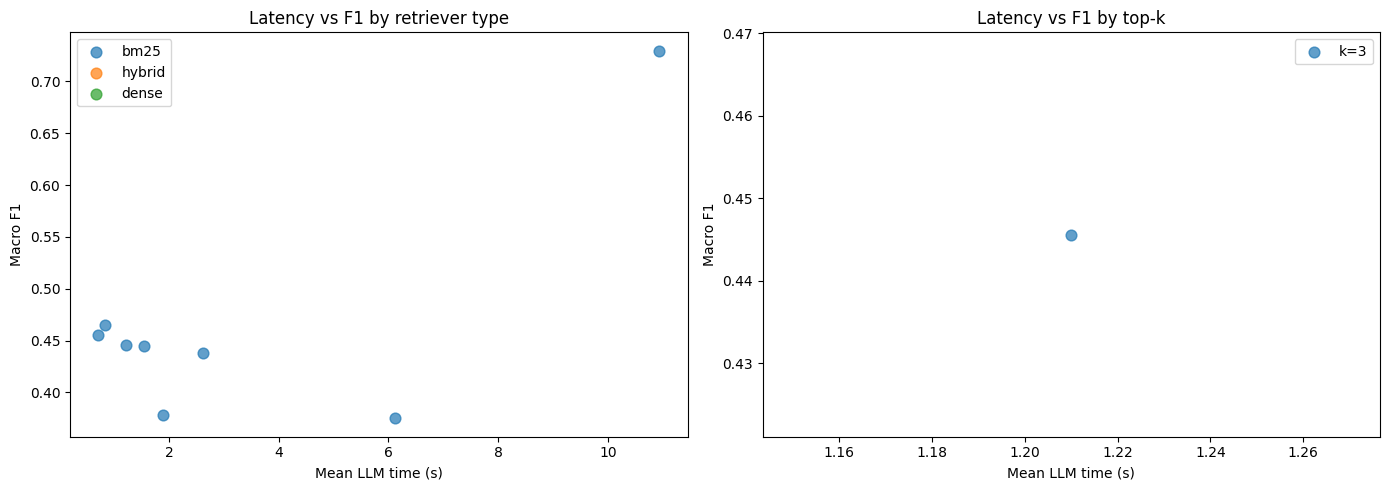

In [24]:
# CELL 15 — Latency vs F1 Plot
# Scatter plot comparing inference speed against classification accuracy.
# Helps identify configurations that are both fast and accurate —
# a configuration in the top-left is ideal (high F1, low latency).


fig, axes_arr = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — each retriever type gets its own colour
# shows whether retrieval method affects the speed/accuracy trade-off
for ret in CFG["retriever_types"]:
    sub = df_summary[df_summary["retriever"] == ret]
    axes_arr[0].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=ret, alpha=0.7, s=60)
axes_arr[0].set_xlabel("Mean LLM time (s)")
axes_arr[0].set_ylabel("Macro F1")
axes_arr[0].set_title("Latency vs F1 by retriever type")
axes_arr[0].legend()

# Right plot — each top-k value gets its own colour
# shows whether retrieving more chunks improves F1 at the cost of speed
for k in CFG["top_k_values"]:
    sub = df_summary[df_summary["top_k"] == k]
    axes_arr[1].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=f"k={k}", alpha=0.7, s=60)
axes_arr[1].set_xlabel("Mean LLM time (s)")
axes_arr[1].set_ylabel("Macro F1")
axes_arr[1].set_title("Latency vs F1 by top-k")
axes_arr[1].legend()

plt.tight_layout()
plt.show()

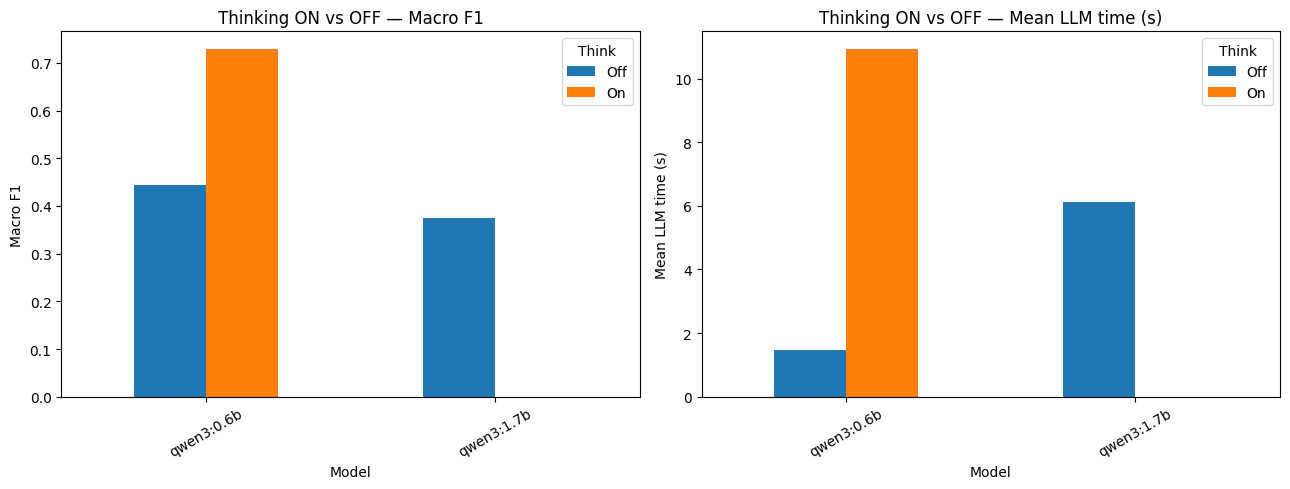

In [25]:
# CELL 16 — Thinking Mode Comparison Plot
# Bar chart comparing thinking ON vs OFF across models for two metrics:
#   Left  — macro F1 (does thinking improve accuracy?)
#   Right — mean LLM time (how much slower is thinking mode?)

# Summarise results grouped by model and thinking mode
think_summary = summarise(df_results, ["model", "think"])

fig, axes_arr = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes_arr,
    ["macro_f1",    "mean_llm_s"],
    ["Macro F1",    "Mean LLM time (s)"],
):
    # Pivot so rows=models, columns=think on/off — makes bar chart easy to plot
    pivot = think_summary.pivot(index="model", columns="think", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Thinking ON vs OFF — {title}")
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    ax.legend(title="Think", labels=["Off", "On"])
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Best configuration:
model          qwen3:0.6b
retriever            bm25
top_k                   5
prompt_type     zero_shot
think                True
accuracy           0.7333
macro_f1           0.7296
mean_llm_s          10.94


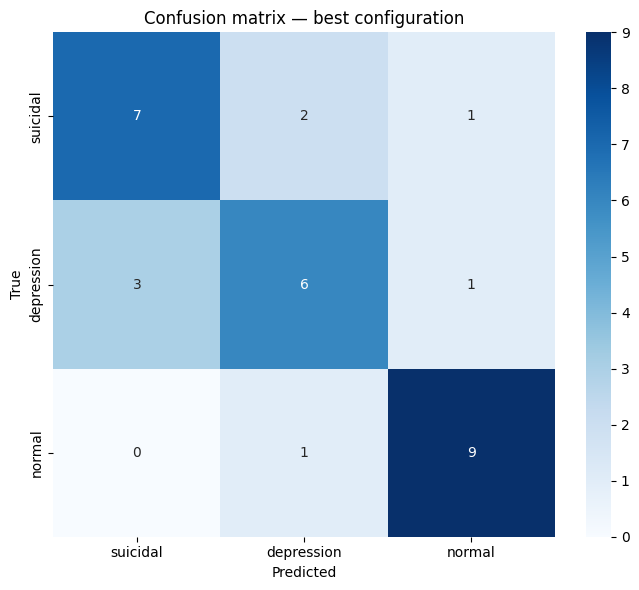


Classification report:
              precision    recall  f1-score   support

    suicidal       0.70      0.70      0.70        10
  depression       0.67      0.60      0.63        10
      normal       0.82      0.90      0.86        10

    accuracy                           0.73        30
   macro avg       0.73      0.73      0.73        30
weighted avg       0.73      0.73      0.73        30



In [26]:
# CELL 17 — Best Configuration Analysis
# Identifies the best performing configuration by macro-F1 and produces:
#   - A confusion matrix showing where the model makes errors
#   - A full classification report with per-class precision, recall, F1
# The confusion matrix is particularly useful for spotting if the model
# confuses adjacent severity levels (e.g. mild vs moderate) more than
# distant ones (e.g. minimum vs severe), which is clinically expected.


# df_summary is sorted by macro_f1 descending so iloc[0] is the best config
best_row = df_summary.iloc[0]
print("Best configuration:")
print(best_row[["model","retriever","top_k","prompt_type","think",
                "accuracy","macro_f1","mean_llm_s"]].to_string())

# Filter raw results to only rows matching the best configuration
mask = (
    (df_results["model"]       == best_row["model"]) &
    (df_results["retriever"]   == best_row["retriever"]) &
    (df_results["top_k"]       == best_row["top_k"]) &
    (df_results["prompt_type"] == best_row["prompt_type"]) &
    (df_results["think"]       == best_row["think"])
)
best_df = df_results[mask]

# Confusion matrix — rows are true labels, columns are predicted labels
# diagonal = correct predictions, off-diagonal = errors
cm = confusion_matrix(best_df["true_label"], best_df["predicted"],
                      labels=CFG["labels"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG["labels"], yticklabels=CFG["labels"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — best configuration")
plt.tight_layout()
plt.show()

# Per-class breakdown — shows which severity levels are hardest to classify
print("\nClassification report:")
print(classification_report(best_df["true_label"], best_df["predicted"],
                             labels=CFG["labels"], zero_division=0))

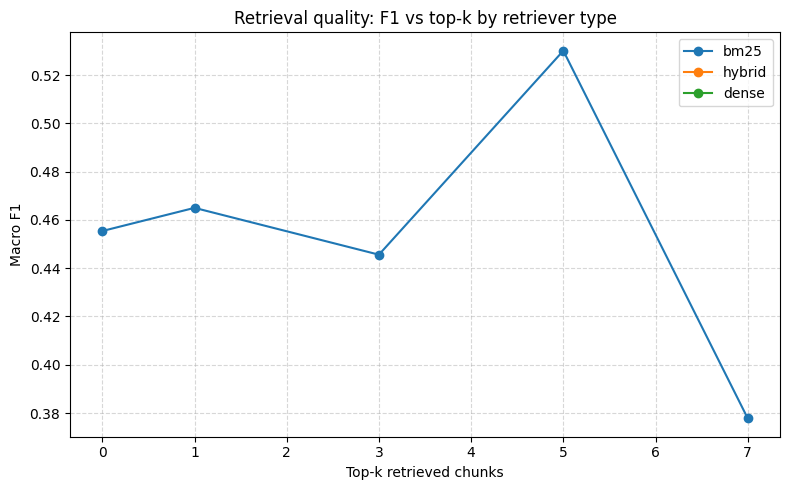

In [27]:
# CELL 18 — Top-k Sweep Plot
# Line chart showing how F1 changes as more chunks are retrieved (k=1,3,5,7)
# for each retriever type. Helps answer RQ1 — what is the optimal k?
# Expected pattern: F1 improves with k up to a point then plateaus or drops
# as irrelevant chunks start adding noise to the prompt.


# Summarise grouped by retriever and top-k
topk_summary = summarise(df_results, ["retriever", "top_k"])

fig, ax = plt.subplots(figsize=(8, 5))

# One line per retriever — sorted by k so the line plots left to right
for ret in CFG["retriever_types"]:
    sub = topk_summary[topk_summary["retriever"] == ret].sort_values("top_k")
    ax.plot(sub["top_k"], sub["macro_f1"], marker="o", label=ret)

ax.set_xlabel("Top-k retrieved chunks")
ax.set_ylabel("Macro F1")
ax.set_title("Retrieval quality: F1 vs top-k by retriever type")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

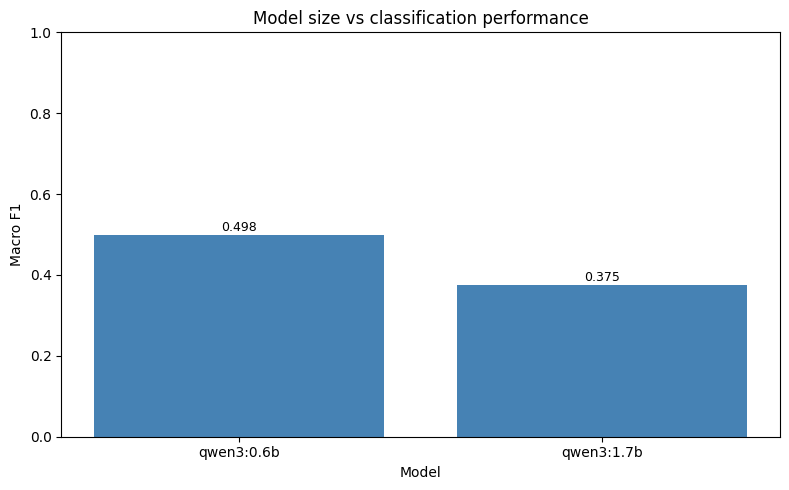

In [28]:
# CELL 19 — Model Size vs Performance Plot
# Bar chart comparing macro-F1 across model sizes (0.6b vs 1.7b).
# Answers RQ2 — does a larger model classify depression severity better?
# F1 values are annotated on top of each bar for easy reading.

# Summarise grouped by model only — averages across all other variables
model_summary = summarise(df_results, ["model"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_summary["model"], model_summary["macro_f1"], color="steelblue")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.set_title("Model size vs classification performance")
ax.set_ylim(0, 1)

# Annotate each bar with its exact F1 value
for i, row in model_summary.iterrows():
    ax.text(i, row["macro_f1"] + 0.01, f"{row['macro_f1']:.3f}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
# CELL 20 — Save Results and Error Analysis
# Saves two CSV files and prints a sample of misclassified posts:
#   rag_results_summary.csv        — aggregated metrics per configuration
#   error_analysis_best_config.csv — posts the best configuration got wrong
# The error analysis is useful for qualitative review — checking whether
# misclassifications are reasonable (e.g. mild predicted as moderate)
# or severe errors (e.g. minimum predicted as severe).

# Save the full summary table — one row per configuration
df_summary.to_csv("rag_results_summary.csv", index=False)
print("Summary saved to rag_results_summary.csv")

# Extract misclassified posts from the best configuration for error analysis
errors = best_df[best_df["correct"] == 0][
    ["true_label", "predicted", "answer_text", "chunk_ids"]
].reset_index(drop=True)
errors.to_csv("error_analysis_best_config.csv", index=False)
print(f"Error analysis: {len(errors)} misclassified posts saved to error_analysis_best_config.csv")

# Print a sample of errors — shows true label, predicted label, and model output
# chunk_ids shows which CDDR chunks were retrieved — useful for checking
# whether wrong predictions were caused by poor retrieval
print("\nSample errors:")
for _, r in errors.head(5).iterrows():
    print(f"  true={r['true_label']:8}  pred={r['predicted']:8}  output: {r['answer_text'][:80]}")

Summary saved to rag_results_summary.csv
Error analysis: 8 misclassified posts saved to error_analysis_best_config.csv

Sample errors:
  true=suicidal  pred=depression  output: Label: depression  
Reason: The individual experiences persistent sadness, anxie
  true=suicidal  pred=depression  output: Label: depression  
Reason: The post expresses a state of being overwhelmed, fee
  true=suicidal  pred=normal    output: Label: normal  
Reason: The post expresses frustration or a coping mechanism, wh
  true=depression  pred=suicidal  output: Label: suicidal  
Reason: The post expresses suicidal thoughts, indicating a pot
  true=depression  pred=suicidal  output: Label: suicide  
Reason: The individual expresses suicidal thoughts due to the i
